# ETF Momentum: Causal DML Estimation

Does momentum *cause* lower future ETF returns, or is the observed reversal
an artifact of volatility and regime confounders? This notebook applies DML
to the skip-recent momentum signal (`skip_recent_6_1`) - 6-month returns
skipping the most recent month - across the 99-ETF cross-asset universe.

**Treatment rationale**: Skip-recent momentum is the primary signal from Ch6's
strategy definition. Volatility at two horizons (21d, 126d), a yield-curve
regime indicator, and yield curve slope are the key confounders because
momentum correlates with all four through the risk-on/risk-off cycle.

**Learning Objectives**:
- Quantify how much volatility and regime confounders distort momentum estimates
- Test whether the momentum–return relationship survives block permutation
- Save orthogonalized treatment contributions for downstream portfolio sizing

**Book Reference**: Chapter 15, Section 15.6 (Cross-Dataset Causal Evidence)

**Prerequisites**: `03_financial_features.py`, `04_model_based_features.py`

## Identifying Assumptions

DML estimates a causal effect under three assumptions:
1. **Conditional ignorability**: No unobserved confounders - all backdoor paths
   between treatment and outcome are blocked by the observed confounders.
2. **Overlap (positivity)**: Every unit has a nonzero probability of receiving
   any treatment level, conditional on confounders.
3. **SUTVA**: One unit's treatment doesn't affect another's outcome.

These are untestable. The refutation test below provides indirect evidence
but cannot prove the assumptions hold.

**Research-design limitations.** This stability analysis uses the fixed 99-ETF
research universe and the materialized financial-feature panel. The `regime`
and `yield_curve_slope` confounders therefore reflect finalized FRED values,
not point-in-time vintages. Their feature timestamps are used as recorded;
the analysis does not claim that those macro observations were tradable at
the same close. These limitations narrow the causal interpretation to this
retrospective research panel.

In [1]:
"""Causal DML - walk-forward estimation with refutation tests."""

import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yaml

import utils.style  # noqa: F401 - activates the ML4T visual style
from case_studies.utils.causal import (
    classify_refutation,
    embargo_from_buffer,
    format_dml_summary,
    register_causal_run,
    run_dml_analysis,
)
from utils.modeling import load_configs, load_modeling_dataset
from utils.paths import get_case_study_dir
from utils.style import COLORS, add_message_title

warnings.filterwarnings("ignore")

In [2]:
CASE_STUDY_ID = "etfs"
PRIMARY_LABEL = ""
MAX_SYMBOLS = 0
RANDOM_SEED = 42
CV_FOLDS = 5
MAX_SAMPLES = 0
N_PLACEBO = 100

In [3]:
CASE_DIR = get_case_study_dir(CASE_STUDY_ID)

# Resolve label from setup.yaml if not overridden
setup = yaml.safe_load((CASE_DIR / "config" / "setup.yaml").read_text())
if not PRIMARY_LABEL:
    PRIMARY_LABEL = setup["labels"]["primary"]

# Load DML config and apply Papermill overrides
causal_configs = load_configs(CASE_STUDY_ID, PRIMARY_LABEL, "causal_dml")
dml_cfg = causal_configs[0]

for key, val in [
    ("n_folds", CV_FOLDS),
    ("n_placebo", N_PLACEBO),
    ("max_samples", MAX_SAMPLES),
    ("seed", RANDOM_SEED),
]:
    if dml_cfg.get(key, val) != val:
        dml_cfg[key] = val

CV_FOLDS = dml_cfg.get("n_folds", 5)
N_PLACEBO = dml_cfg.get("n_placebo", 100)
MAX_SAMPLES = dml_cfg.get("max_samples", 0)
RANDOM_SEED = dml_cfg.get("seed", 42)

print(f"DML config: {dml_cfg['config_name']}")

# Read causal config from setup.yaml
causal_cfg = setup.get("causal", {})
TREATMENT_COL = causal_cfg.get("treatment", "")
CONFOUNDER_COLS = causal_cfg.get("confounders", [])
DML_METHOD = causal_cfg.get("method", "walk_forward_dml")

if not TREATMENT_COL:
    raise ValueError(
        f"No causal.treatment in {CASE_STUDY_ID}/setup.yaml. "
        "Add a 'causal:' section with treatment and confounders."
    )

np.random.seed(RANDOM_SEED)

print("Causal DML Configuration:")
print(f"  Case study: {CASE_STUDY_ID}")
print(f"  Treatment: {TREATMENT_COL}")
print(f"  Outcome: {PRIMARY_LABEL}")
print(f"  Confounders: {CONFOUNDER_COLS}")
print(f"  CV folds: {CV_FOLDS}")
print(f"  Placebo reps: {N_PLACEBO}")

DML config: dml
Causal DML Configuration:
  Case study: etfs
  Treatment: skip_recent_6_1
  Outcome: fwd_ret_21d
  Confounders: ['vol_21d', 'vol_126d', 'regime', 'yield_curve_slope']
  CV folds: 5
  Placebo reps: 100


## 1. Load Artifacts

Load pre-computed features, temporal features, and labels using the
shared modeling infrastructure.

In [4]:
mds = load_modeling_dataset(CASE_STUDY_ID, PRIMARY_LABEL, max_symbols=MAX_SYMBOLS)

dataset = mds.dataset
feature_names = mds.feature_names
label_col = mds.label_col
date_col = mds.date_col
entity_cols = mds.entity_cols

# Verify treatment and confounders are in features
available = set(dataset.columns)
assert TREATMENT_COL in available, (
    f"Treatment '{TREATMENT_COL}' not found in features: {sorted(available)}"
)

missing_conf = [c for c in CONFOUNDER_COLS if c not in available]
if missing_conf:
    print(f"WARNING: Missing confounders {missing_conf}, dropping them")
    CONFOUNDER_COLS = [c for c in CONFOUNDER_COLS if c in available]

assert len(CONFOUNDER_COLS) >= 1, "Need at least 1 confounder for DML"

print(f"\nDataset: {len(dataset):,} rows x {len(feature_names)} features")
print(f"Label: {label_col} | Date: {date_col} | Entities: {entity_cols}")


Dataset: 394,233 rows x 71 features
Label: fwd_ret_21d | Date: timestamp | Entities: ['symbol']


## 2. Prepare Analysis Data

Convert to pandas, sort by time, and subset by complete dates if needed.

In [5]:
# Select analysis columns
analysis_cols = [date_col] + entity_cols + [TREATMENT_COL, label_col] + CONFOUNDER_COLS
analysis_cols = list(dict.fromkeys(analysis_cols))  # deduplicate

merged_clean = (
    dataset.select([c for c in analysis_cols if c in available])
    .drop_nulls()
    .sort(date_col)
    .to_pandas()
)

EMBARGO_PERIODS = embargo_from_buffer(mds.label_buffer)

BLOCK_SIZE = EMBARGO_PERIODS

# Causal estimation is a development-stage diagnostic. Keep the untouched
# holdout out of nuisance fitting, effect estimation, and refutation tests.
DEVELOPMENT_END = max(pd.Timestamp(split["val_end"]) for split in mds.splits)
merged_clean = merged_clean[merged_clean[date_col] <= DEVELOPMENT_END].copy()
print(f"Development window ends: {DEVELOPMENT_END.date()} (holdout excluded)")

# Temporal subset if too large. Keep complete panel dates so neither the sample
# cap nor the downstream cross-fitting logic can split a date across boundaries.
if MAX_SAMPLES > 0 and len(merged_clean) > MAX_SAMPLES:
    date_counts = merged_clean.groupby(date_col, sort=True).size().iloc[::-1]
    selected_dates = date_counts.index[date_counts.cumsum() <= MAX_SAMPLES]
    if len(selected_dates) == 0:
        selected_dates = date_counts.index[:1]
    print(
        f"Taking {len(selected_dates):,} complete recent dates "
        f"({date_counts.loc[selected_dates].sum():,} rows) from {len(merged_clean):,} rows"
    )
    merged_clean = merged_clean[merged_clean[date_col].isin(selected_dates)].copy()

Development window ends: 2023-12-29 (holdout excluded)


> **Note**: Production estimation uses the full development window. A positive
> `MAX_SAMPLES` override is available only for execution tests; it retains
> complete recent dates and therefore estimates a recent-period effect.

In [6]:
print(f"\nAnalysis data: {len(merged_clean):,} rows")
print(f"Date range: {merged_clean[date_col].min()} to {merged_clean[date_col].max()}")
print(f"Embargo: {EMBARGO_PERIODS} periods | Block size: {BLOCK_SIZE}")
if entity_cols:
    print(f"Entities: {merged_clean[entity_cols[0]].nunique()}")


Analysis data: 349,500 rows
Date range: 2007-01-03 00:00:00 to 2023-12-29 00:00:00
Embargo: 21 periods | Block size: 21
Entities: 99


## 3. Run DML Analysis

Full pipeline: naive OLS baseline, date-level DML with walk-forward CV and
embargo, and entity-aware within-symbol temporal block permutation. Driscoll-Kraay standard errors
use a bandwidth of $\max(h-1,\ \lfloor T^{1/3} \rfloor)$, where $T$ is the
number of dates. The 21-day overlapping label induces MA(20) structure, so
the bandwidth must be at least 20.

In [7]:
results = run_dml_analysis(
    merged_clean,
    treatment_col=TREATMENT_COL,
    outcome_col=label_col,
    confounder_cols=CONFOUNDER_COLS,
    n_folds=CV_FOLDS,
    embargo=EMBARGO_PERIODS,
    n_placebo=N_PLACEBO,
    block_size=BLOCK_SIZE,
    seed=RANDOM_SEED,
    horizon=EMBARGO_PERIODS,
    time_col=date_col,
)

print(format_dml_summary(results))

DML ANALYSIS SUMMARY
Observations: 349,500
HAC bandwidth: 20 lags (max of horizon-1 and cube-root)

Naive OLS effect:  -0.003658
DML effect:        0.003459
  SE (IID):        0.001183
  SE (HAC):        0.012355
  t-stat (HAC):    0.28
  p-value (HAC):   0.7795

Confounding bias:  -0.007118 (-205.8%)

Refutation (block permutation):
  Z-score:      0.16
  Empirical p:  0.7600
  Classification: Fails
  Placebos:     100


**ETF Momentum - Interpretation**: The full-development DML estimate is
+0.0045 with a Driscoll-Kraay standard error of 0.0127 (p=0.722). Its
confidence interval spans economically meaningful positive and negative
values, so the data do not identify a momentum effect after controlling for
volatility, regime, and yield-curve slope. Naive OLS is slightly negative
(-0.0031), while orthogonalization changes the point estimate's sign; neither
point estimate supports a directional conclusion.

Entity-aware within-symbol temporal block permutation also fails to distinguish the observed
estimate from placebo assignments (empirical p=0.72). The two diagnostics
agree on a null result. This is a development-stage stability analysis; the
ETF holdout remains sealed.

## 4. Statistical Assessment

Confounding bias is defined as:

$$\text{Bias \%} = \frac{\hat{\theta}_{\text{naive}} - \hat{\theta}_{\text{DML}}}{|\hat{\theta}_{\text{DML}}|} \times 100$$

Positive values mean naive OLS overstates the absolute effect.

In [8]:
dml_result = results["dml_result"]
naive_effect = results["naive_effect"]
dml_effect = dml_result["theta"]
se_hac = dml_result["se_hac"]
bias_pct = results["confounding_bias_pct"]

# p-value computed in run_dml_analysis (no duplication)
p_value = results["p_value_hac"]

ref = results.get("refutation", {})
p_value_perm = ref.get("empirical_p", 1.0)
ref_class = ref.get("refutation_class", classify_refutation(p_value_perm))

print("Statistical significance:")
print(f"  p-value (HAC): {p_value:.4f}")
print(f"  Significant at 5%: {'Yes' if p_value < 0.05 else 'No'}")
if ref:
    print(f"  Refutation: {ref_class} (p={p_value_perm:.4f})")

Statistical significance:
  p-value (HAC): 0.7795
  Significant at 5%: No
  Refutation: Fails (p=0.7600)


> **Interpreting the bias percentage**: The normalization divides by the DML
> effect. When that estimate is near zero, the percentage is unstable and can
> exceed 100% even though both raw effects are small. Here the effect, standard
> error, and placebo distribution carry more information than the normalized
> bias statistic.

### Permutation Distribution

The observed DML effect (red line) against the distribution of placebo
effects under block permutation of the treatment.

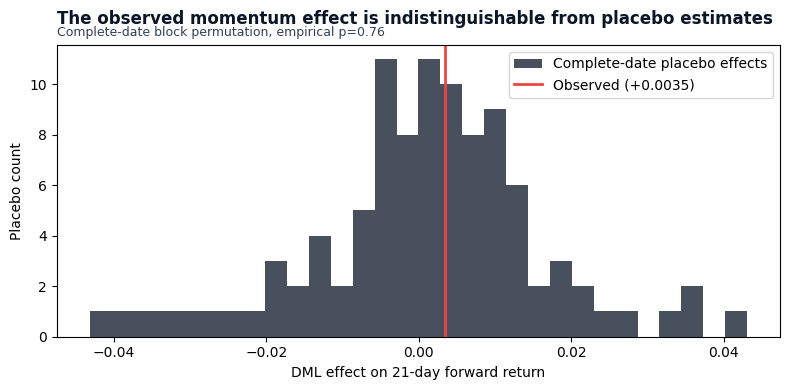

In [9]:
placebo_arr = np.array(ref.get("placebo_effects", []))
if len(placebo_arr) > 0:
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.hist(
        placebo_arr,
        bins=30,
        color=COLORS["blue"],
        alpha=0.75,
        label="Entity-aware within-symbol temporal block permutation effects",
    )
    ax.axvline(
        dml_effect,
        color=COLORS["negative"],
        linewidth=2,
        label=f"Observed ({dml_effect:+.4f})",
    )
    ax.set_xlabel("DML effect on 21-day forward return")
    ax.set_ylabel("Placebo count")
    add_message_title(
        ax,
        "The observed momentum effect is indistinguishable from placebo estimates",
        subtitle=(
            f"Entity-aware within-symbol temporal block permutation, empirical p={p_value_perm:.2f}"
        ),
    )
    ax.legend()
    fig.tight_layout()
    plt.show()

## 5. Register Results

In [10]:

# Per-observation treatment contributions from DML residuals
T_res = dml_result.get("T_res", np.full(len(merged_clean), np.nan))
Y_res = dml_result.get("Y_res", np.full(len(merged_clean), np.nan))

# Residuals are NaN for training-only obs; align to merged_clean length
# (residuals cover the full analysis data before subsampling)
n_analysis = len(merged_clean)
if len(T_res) > n_analysis:
    # Residuals from full data; take tail matching our subsample
    T_res = T_res[-n_analysis:]
    Y_res = Y_res[-n_analysis:]

symbol_col = entity_cols[0] if entity_cols else None

predictions = pd.DataFrame(
    {
        "timestamp": pd.to_datetime(merged_clean[date_col]),
        "symbol": merged_clean[symbol_col].values if symbol_col else "ALL",
        "y_true": merged_clean[label_col].values,
        "treatment_value": merged_clean[TREATMENT_COL].values,
        "treatment_residual": T_res,
        "outcome_residual": Y_res,
        "treatment_contribution": T_res * dml_effect,
        "ate": dml_effect,
        "ate_se": se_hac,
    }
)

# Prepare the standardized registry payload.
summary = {
    "treatment": TREATMENT_COL,
    "outcome": label_col,
    "confounders": CONFOUNDER_COLS,
    "n_observations": dml_result["n_obs"],
    "naive_effect": float(naive_effect),
    "dml_effect": float(dml_effect),
    "dml_se_iid": float(dml_result["se_iid"]),
    "dml_se_hac": float(se_hac),
    "confounding_bias_pct": float(bias_pct),
    "p_value_hac": float(p_value),
    "hac_maxlags": int(results.get("hac_maxlags", 0)),
    "refutation_p_value": float(p_value_perm),
    "refutation_class": ref_class,
}

register_causal_run(
    case_study_id=CASE_STUDY_ID,
    label=PRIMARY_LABEL,
    results=results,
    predictions=predictions,
    treatment_col=TREATMENT_COL,
    confounder_cols=CONFOUNDER_COLS,
    n_folds=CV_FOLDS,
    embargo=EMBARGO_PERIODS,
    time_col=date_col,
    block_size=BLOCK_SIZE,
    n_placebo=N_PLACEBO,
    seed=RANDOM_SEED,
    horizon=EMBARGO_PERIODS,
    max_samples=MAX_SAMPLES,
    development_end=DEVELOPMENT_END.date().isoformat(),
    notebook="12_causal_dml",
)

  -> registered causal_dml (causal_hash=1b6a832db69b, p_hac=0.7795)


'1b6a832db69b'

## Key Takeaways

1. **No stable directional effect**: After orthogonalizing for volatility
   (21d, 126d), regime, and yield-curve slope, the skip-recent momentum effect
   on 21-day ETF returns is +0.0045 per unit (Driscoll-Kraay SE 0.0127,
   t≈0.36, p=0.722). The confidence interval includes zero.

2. **The sign is not robust to adjustment**: Naive OLS gives -0.0031, while
   the orthogonalized estimate is slightly positive. With both effects close
   to zero, the sign change is evidence against a directional interpretation,
   not evidence for a positive effect.

3. **HAC and refutation agree**: Entity-aware within-symbol temporal block permutation gives
   empirical p=0.72, so the observed estimate is typical of placebo
   assignments. Both tests support the corrected null conclusion, and the
   untouched holdout is not consulted.

**Next**: [`14_backtest`](14_backtest.ipynb) translates the registered validation candidates into
strategy backtests and tests whether predictive rank correlation survives portfolio construction.

**Book**: Section 15.6 discusses the ETF result as part of the cross-dataset trial.

In [11]:
print("\n" + "=" * 60)
print(f"CHAPTER 15 RESULTS: {CASE_STUDY_ID} causal DML")
print("=" * 60)
for key, value in summary.items():
    if isinstance(value, float):
        print(f"  {key}: {value:.6f}")
    else:
        print(f"  {key}: {value}")

print(f"\n[OK] Causal DML analysis complete for {CASE_STUDY_ID}")


CHAPTER 15 RESULTS: etfs causal DML
  treatment: skip_recent_6_1
  outcome: fwd_ret_21d
  confounders: ['vol_21d', 'vol_126d', 'regime', 'yield_curve_slope']
  n_observations: 309888
  naive_effect: -0.003658
  dml_effect: 0.003459
  dml_se_iid: 0.001183
  dml_se_hac: 0.012355
  confounding_bias_pct: -205.764557
  p_value_hac: 0.779510
  hac_maxlags: 20
  refutation_p_value: 0.760000
  refutation_class: Fails

[OK] Causal DML analysis complete for etfs
